# Linear Regression Baseline
Same dataset, same feature set as `build_model_weather.ipynb` (LightGBM).
This is the first model in the comparison chain — a plain Linear Regression
with one-hot encoded categoricals and scaled numeric features.

**Split strategy note:** for the current single-day dataset, a random
group-split by `trip_id` is fine — there's no meaningful time ordering
within one day. Once the dataset grows to span multiple months, switch
`USE_CHRONOLOGICAL_SPLIT` to `True` below: a random split across months lets
the model implicitly see future weather/ridership patterns during training,
which inflates test performance and isn't a fair evaluation. Change this
setting consistently in the LightGBM notebook too, so the two stay
comparable.

In [19]:
import numpy as np
import polars as pl
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import joblib

In [20]:
DATA_PATH = "raw/processed_gtfs/baseline_dataset.parquet"

# Toggle this once the dataset spans multiple months (see note above).
# Requires a `service_date` column in df.
USE_CHRONOLOGICAL_SPLIT = False
CHRONOLOGICAL_SPLIT_DATE = "2026-06-01"  # train < this date, test >= this date

df = pl.read_parquet(DATA_PATH)
print(df.shape)

TARGET = "travel_time"
CATEGORICAL = ["route_id", "direction_id", "shape_id", "service_id", 'is_raining', 'is_snowing', 'is_fog', "is_weekend",
    "is_federal_holiday",
    "is_school_day",
    "has_major_event",]
NUMERIC = [
    "stop_sequence", "trip_progress",
    "hour", "weekday", "month", "is_peak",
    "scheduled_arrival", "scheduled_departure", "scheduled_segment_time",
    "stop_lat", "stop_lon", "latitude", "longitude", "bearing",
    'temperature_c', 'precipitation_mm', 'snowfall_cm', 'windspeed_kmh', 'weathercode',
    'segment_length',
    'scheduled_segment_speed_mps',
    'upstream_delay_seconds',
    'speed_mps',
    'headway_seconds',
    "ridership",
    "transfers",
]

FEATURES = CATEGORICAL + NUMERIC

(56764, 40)


## Split
Two modes, controlled by `USE_CHRONOLOGICAL_SPLIT` above:
- **Group split** (current default, single-day data): random 80/20 split by
  `trip_id` so no trip's rows leak between train and test.
- **Chronological split** (switch on once spanning multiple months): train
  on everything before `CHRONOLOGICAL_SPLIT_DATE`, test on everything after
  — evaluates the model on genuinely unseen future dates, which is the
  honest test for this kind of time-ordered data.

In [21]:
if USE_CHRONOLOGICAL_SPLIT:
    assert "service_date" in df.columns, "service_date column required for chronological split"

    train_df = df.filter(pl.col("service_date") < CHRONOLOGICAL_SPLIT_DATE)
    test_df = df.filter(pl.col("service_date") >= CHRONOLOGICAL_SPLIT_DATE)

    print(f"[chronological split @ {CHRONOLOGICAL_SPLIT_DATE}]")
    print(f"train: {train_df.shape} | test: {test_df.shape}")
    print(f"train trips: {train_df['trip_id'].n_unique():,} | "
          f"test trips: {test_df['trip_id'].n_unique():,} | "
          f"overlap: {len(set(train_df['trip_id']) & set(test_df['trip_id']))}")
else:
    groups = df["trip_id"].to_numpy()
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(df, groups=groups))

    train_df = df[train_idx]
    test_df = df[test_idx]

    print("[random group split by trip_id]")
    print(f"train: {train_df.shape} | test: {test_df.shape}")
    print(f"train trips: {train_df['trip_id'].n_unique():,} | "
          f"test trips: {test_df['trip_id'].n_unique():,} | "
          f"overlap: {len(set(train_df['trip_id']) & set(test_df['trip_id']))}")

[random group split by trip_id]
train: (45363, 40) | test: (11401, 40)
train trips: 996 | test trips: 250 | overlap: 0


## Convert to pandas
Unlike LightGBM, sklearn's LinearRegression can't consume raw categorical
dtypes or booleans directly — those get one-hot encoded in the pipeline
below. Numeric features get scaled, since LR (unlike tree models) is
sensitive to feature magnitude.

In [22]:
def to_pandas_typed(pl_df: pl.DataFrame) -> pd.DataFrame:
    cols = {}
    for col in FEATURES:
        s = pl_df[col]
        if col in CATEGORICAL:
            cols[col] = pd.Series(s.to_list(), dtype="category")
        else:
            cols[col] = s.to_numpy()
    return pd.DataFrame(cols)

X_train = to_pandas_typed(train_df)
X_test = to_pandas_typed(test_df)
y_train = train_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

## Preprocessing pipeline
- `OneHotEncoder` for categoricals (`handle_unknown="ignore"` so any category
  seen only in test doesn't break prediction). **`sparse_output=True`** —
  at single-day scale (~57K rows) this makes little difference, but once the
  dataset grows to ~4 months (~millions of rows), a dense one-hot matrix
  would use several GB of memory unnecessarily. Sparse output avoids that
  entirely and `LinearRegression` handles sparse input natively, so there's
  no downside to leaving this on now.
- `StandardScaler` for numeric features (mean 0, unit variance — needed for
  LR coefficients to be meaningful and for optimization to converge cleanly)

Wrapped in a single `Pipeline` so preprocessing + model are one saved object,
same convenience as saving the LightGBM booster in one file.

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CATEGORICAL),
        ("num", StandardScaler(), NUMERIC),
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", LinearRegression()),
])

model.fit(X_train, y_train)
print("model fit complete")

model fit complete


## Evaluate
Same metrics (MAE, RMSE, R²) and the same naive baseline comparison
(predicting `scheduled_segment_time` as-is) used in the LightGBM notebook,
so the two are directly comparable.

In [24]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE:  {mae:.1f} sec")
print(f"RMSE: {rmse:.1f} sec")
print(f"R2:   {r2:.4f}")
mape = mean_absolute_percentage_error(y_test, preds)
wape = np.abs(y_test - preds).sum() / np.abs(y_test).sum()

print(f"MAPE: {mape*100:.1f}%  (caution: unstable if travel_time has near-zero rows)")
print(f"WAPE: {wape*100:.1f}%")
# naive baseline for comparison: predict the scheduled segment time as-is
naive_preds = test_df["scheduled_segment_time"].to_numpy()
naive_mae = mean_absolute_error(y_test, naive_preds)
print(f"\nNaive baseline (scheduled_segment_time only) MAE: {naive_mae:.1f} sec")
print(f"Improvement over naive: {(1 - mae / naive_mae) * 100:.1f}%")
naive_wape = np.abs(y_test - naive_preds).sum() / np.abs(y_test).sum()
print(f"Naive baseline WAPE: {naive_wape*100:.1f}%")

MAE:  37.1 sec
RMSE: 64.4 sec
R2:   0.3609
MAPE: 80.6%  (caution: unstable if travel_time has near-zero rows)
WAPE: 37.6%

Naive baseline (scheduled_segment_time only) MAE: 47.4 sec
Improvement over naive: 21.7%
Naive baseline WAPE: 48.0%


## Coefficients
LR's analogue to LightGBM's `feature_importances_` — the learned
coefficient per (encoded) feature. Larger absolute value = bigger effect on
predicted travel time, holding other features fixed (since inputs are
standardized, coefficients are roughly comparable across features).

shape: (88, 3)
┌─────────────────────────────┬─────────────┬─────────────────┐
│ feature                     ┆ coefficient ┆ abs_coefficient │
│ ---                         ┆ ---         ┆ ---             │
│ str                         ┆ f64         ┆ f64             │
╞═════════════════════════════╪═════════════╪═════════════════╡
│ num__segment_length         ┆ 37.209948   ┆ 37.209948       │
│ num__stop_lat               ┆ -27.059792  ┆ 27.059792       │
│ num__stop_lon               ┆ 21.533712   ┆ 21.533712       │
│ cat__shape_id_M1010087      ┆ -20.300739  ┆ 20.300739       │
│ cat__shape_id_M040917       ┆ 18.821211   ┆ 18.821211       │
│ …                           ┆ …           ┆ …               │
│ cat__is_fog_0               ┆ 1.7764e-15  ┆ 1.7764e-15      │
│ cat__has_major_event_0.0    ┆ 1.7764e-15  ┆ 1.7764e-15      │
│ num__snowfall_cm            ┆ 4.7020e-38  ┆ 4.7020e-38      │
│ cat__is_federal_holiday_0.0 ┆ 0.0         ┆ 0.0             │
│ cat__is_school_day_0.0 

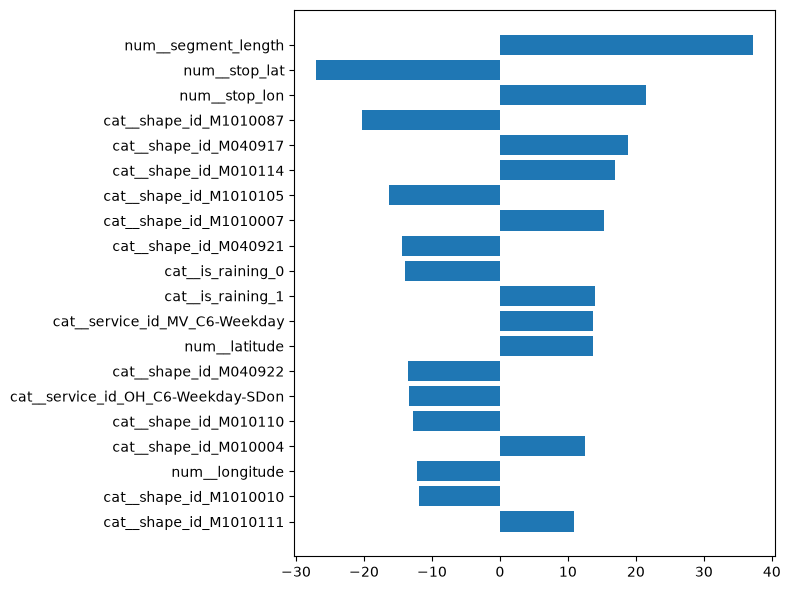

In [25]:
encoded_feature_names = model.named_steps["preprocess"].get_feature_names_out()
coefs = model.named_steps["regressor"].coef_

coef_df = pl.DataFrame({
    "feature": encoded_feature_names,
    "coefficient": coefs,
}).with_columns(pl.col("coefficient").abs().alias("abs_coefficient")).sort("abs_coefficient", descending=True)

print(coef_df)

import matplotlib.pyplot as plt

top = coef_df.head(20).to_pandas()
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["coefficient"])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Save
Saved as a `.pkl` via joblib (not `.txt` — that format is LightGBM's native
booster dump, not applicable here). Naming mirrors the LightGBM model file
so the two are easy to pair up in `models/`.

In [26]:
# joblib.dump(model, "models/lr_weather_segments_delay_and_ridership.pkl")
# print("model saved")